In [231]:
from pathlib import Path

root = Path.cwd().parent
grid_name = 'grid_1'
q_file = root / f'output/{grid_name}/q_mc_episodes_1000000_gamma_0_9_epsilon_0_1.pkl'
path_file = root / f'output/{grid_name}/path_mc_episodes_1000000_gamma_0_9_epsilon_0_1.pkl'


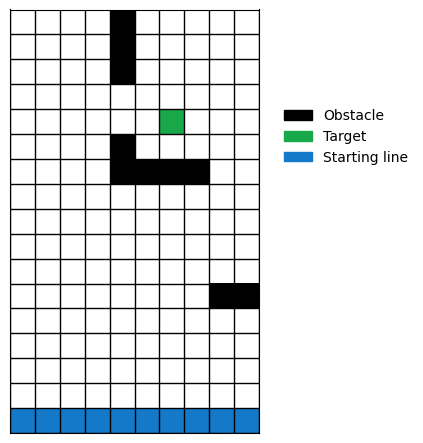

In [232]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

grid = np.loadtxt(root / f'data/grids/{grid_name}.csv', delimiter=',', dtype=int)

cmap = ListedColormap(['white', 'black', '#18a84a', '#1479c9'])

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(grid, cmap=cmap, vmin=0, vmax=3, origin='upper')
ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
ax.grid(which='minor', color='black', linewidth=1)
ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

legend = [
    Patch(facecolor='black', edgecolor='black', label='Obstacle'),
    Patch(facecolor='#18a84a', edgecolor='#18a84a', label='Target'),
    Patch(facecolor='#1479c9', edgecolor='#1479c9', label='Starting line'),
]
ax.legend(handles=legend, loc='center left', bbox_to_anchor=(1.05, 0.7), frameon=False)
plt.show()


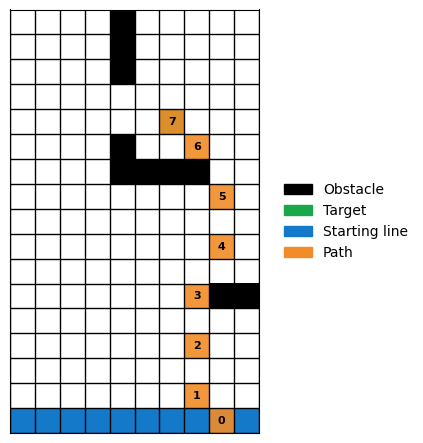

In [233]:
import pickle

with path_file.open('rb') as file:
    path_data = pickle.load(file)

path_states = path_data['path']
path_cells = [(x, y) for x, y, _, _ in path_states]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(grid, cmap=cmap, vmin=0, vmax=3, origin='upper')

for step, (x, y) in enumerate(path_cells):
    ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor='#f28c28', edgecolor='none', alpha=0.9))
    ax.text(x, y, str(step), ha='center', va='center', color='black', fontsize=8, fontweight='bold')

ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
ax.grid(which='minor', color='black', linewidth=1)
ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

legend = [
    Patch(facecolor='black', edgecolor='black', label='Obstacle'),
    Patch(facecolor='#18a84a', edgecolor='#18a84a', label='Target'),
    Patch(facecolor='#1479c9', edgecolor='#1479c9', label='Starting line'),
    Patch(facecolor='#f28c28', edgecolor='#f28c28', label='Path'),
]
ax.legend(handles=legend, loc='center left', bbox_to_anchor=(1.05, 0.5), frameon=False)
plt.show()
